## NLP Quest 01 

# <center>seq2seq로 번역기 만들기</center>

---
1) 데이터 전처리
2) 모델 설계(Bahdanau Attention 사용)
3) 훈련시키기  
   (1) Optimizer & Loss  
   (2) Train_step 구현(Loss 계산 후 반환)  
   (3) 학습 진행 후 시각화   

[ 프로젝트를 위한 디렉토리 생성 ]

$ mkdir -p ~/work/s2s_translation

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [1]:
# 한국어 포함 말뭉치를 이용, 시각화 하기 위해서 matplotlib에 한국어 지원 폰트 변경 

!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece konlpy

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
139 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 139 not upgraded.


In [2]:
"""
[Error]
Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/
MeCab 추가 설치 필요
"""
import subprocess
import sys
import importlib.util

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# mecab-ko 설치
if importlib.util.find_spec("mecab_ko") is None:
    print("Installing mecab-ko...")
    install("mecab-ko")
else:
    print("mecab-ko already installed.")

# mecab-ko-dic 설치
if importlib.util.find_spec("mecab_ko_dic") is None:
    print("Installing mecab-ko-dic...")
    install("mecab-ko-dic")
else:
    print("mecab-ko-dic already installed.")

print("Installation complete!")

mecab-ko already installed.
mecab-ko-dic already installed.
Installation complete!


In [2]:
from mecab_ko import Tagger

tagger = Tagger()

print(tagger.parse("안녕하세요 저는 학생입니다."))

안녕	NNG,*,T,안녕,*,*,*,*
하	XSV,*,F,하,*,*,*,*
세요	EP+EF,*,F,세요,Inflect,EP,EF,시/EP/*+어요/EF/*
저	NP,*,F,저,*,*,*,*
는	JX,*,T,는,*,*,*,*
학생	NNG,*,T,학생,*,*,*,*
입니다	VCP+EF,*,F,입니다,Inflect,VCP,EF,이/VCP/*+ᄇ니다/EF/*
.	SF,*,*,*,*,*,*,*
EOS



In [3]:
import pkgutil

mods = sorted([m.name for m in pkgutil.iter_modules() if "mecab" in m.name.lower()])
print(mods)

['MeCab', 'mecab_ko', 'mecab_ko_dic']


In [4]:
import os
import site

for p in site.getsitepackages():
    print(p)
    print([x for x in os.listdir(p) if "mecab" in x.lower()])

/opt/conda/lib/python3.12/site-packages
['mecab_python3-1.0.12.dist-info', 'MeCab', 'mecab_ko', 'mecab_ko_dic', 'mecab_ko.libs', 'mecab_ko-1.0.2.dist-info', 'mecab_python3.libs', 'mecab_ko_dic-1.0.0.dist-info']


In [5]:
import matplotlib as mpl              # Matplotlib 핵심 라이브러리 (전역 설정 관리용)
import matplotlib.pyplot as plt       # 데이터 시각화를 위한 플로팅 인터페이스
import matplotlib.font_manager as fm   # 시스템 폰트 탐색 및 등록을 위한 폰트 관리 모듈
import matplotlib.ticker as ticker     # 축의 눈금(Tick) 위치 및 형식을 세밀하게 제어하는 모듈
import logging                        # 시스템 로그 제어를 위한 내장 라이브러리

# 로그 레벨을 ERROR로 상향해서, 치명적 문제가 아닐 경우 로그가 뜨지 않음 
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
# .rcParams[]
#     Matplotlib의 전역 스타일(폰트, 색상, 선 두께 등)을 제어하는 딕셔너리 구조의 환경 설정 변수 
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 데이터 전처리

## 프로젝트에 사용될 라이브러리 import

In [6]:
import os
import re
import urllib.request   # 웹상의 URL을 통한 데이터셋 다운로드
import tarfile          # tar.gz 파일 압축 헤제 
import sentencepiece as spm   # 구글에서 개발한 하브워드(Subword) 토크나이저. 텍스트를 단어 조각 단위로 분할 및 인코딩
import pandas as pd
from konlpy.tag import Mecab

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence # pad_sequence: 길이가 다른 문장(시퀀스)들을 가장 긴 문장 길이에 맞춰 패딩(0 추가 등) 텐서로 병합해주는 함수
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm   # 반복문(For loop)의 진행 상황을 콘솔에 시각적인 진행바(Progress Bar)로 표시
import random

# GPU 사용 설정 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(pd.__version__)
print(torch.__version__)
print(mpl.__version__)

2.3.0
2.7.1+cu118
3.10.3


In [7]:
# dataset 다운로드 

# os.path.expanduser
#     사용자 홈 디렉토리를 기준으로 절대 경로를 확장
#     여기서는 시스템 내 'work/s2s_translation/datasets' 폴더를 최종 목적지로 설정
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)
    # exist_ok=True: 해당 폴더가 이미 존재하더라도 에러(FileExistsError)를 발생시키지 않고 그대로 진행

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")


# 데이터셋 다운로드(파일이 없을때만 실행) 
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

# 압축 해제 후 데이터 폴더에 저장 
# tar.gz 압축을 풀면 'korean-english-park.train.en'과 'korean-english-park.train.ko' 파일이 나옴
if not os.path.exists(os.path.join(dataset_dir, "korean-english-park.train.ko")):
    print("tar.gz 압축 해제 중...")
    with tarfile.open(tar_path, 'r:gz') as tar_ref:  # 'r:gz' 모드로 읽기
        tar_ref.extractall(path=dataset_dir)
    print("압축 해제 완료!")



print("데이터셋 디렉토리 파일 목록:", os.listdir(dataset_dir))

데이터셋 디렉토리 파일 목록: ['spa-eng', 'korean-english-park.train.en', 'korean-english-park.train.tar.gz', 'spa-eng.zip', 'korean-english-park.train.ko']


In [8]:
# 데이터 확인 

# 파일 경로 지정
ko_file_path = os.path.join(dataset_dir, "korean-english-park.train.ko")

# 상위 5개 문장만 출력해보기
with open(ko_file_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        line = f.readline()
        print(f"{i+1}번째 문장: {line.strip()}")


# 파일 경로 지정
en_file_path = os.path.join(dataset_dir, "korean-english-park.train.en")

# 상위 5개 문장만 출력해보기
with open(en_file_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        line = f.readline()
        print(f"{i+1}번째 문장: {line.strip()}")

1번째 문장: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
2번째 문장: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
3번째 문장: 그러나 이것은 또한 책상도 필요로 하지 않는다.
4번째 문장: 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
5번째 문장: 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.
1번째 문장: Much of personal computing is about "can you top this?"
2번째 문장: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
3번째 문장: Like all optical mice, But it also doesn't need a desk.
4번째 문장: uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
5번째 문장: Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.


## 데이터 전처리: 정제하기


set 데이터형이 중복을 허용하지 않는다는 것을 활용해 중복된 데이터를 제거하도록 합니다. 데이터의 병렬 쌍이 흐트러지지 않게 주의하세요! 중복을 제거한 데이터를 cleaned_corpus 에 저장합니다.

앞서 정의한 preprocessing() 함수는 한글에서는 동작하지 않습니다. 한글에 적용할 수 있는 정규식을 추가하여 함수를 재정의하세요!

타겟 언어인 영문엔 <start> 토큰과 <end> 토큰을 추가하고 split() 함수를 이용하여 토큰화합니다. 한글 토큰화는 KoNLPy의 mecab 클래스를 사용합니다.

모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다. cleaned_corpus로부터 토큰의 길이가 40 이하인 데이터를 선별하여 eng_corpus와 kor_corpus를 각각 구축하세요.

In [9]:
# 정규식을 확용하여 데이터 정제 

def preprocessing(sentence, is_source=True):

    # 양쪽 공백 제거 
    sentence = sentence.strip() 
        # .strip() : 문자 앞뒤로 붙은 불필요한 공백(스페잇, 탭, 줄바꿈) 잘라냄 

    # re.sub(패턴, 바꿀문자, 원본문자)
    # 한글, 영문, 필수 문장부호 및 공백을 제외한 모든 문자 제거
    # [^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z?.!, ] -> 지정된 문자 외에는 공백으로 대체
    sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z?.!, ]", " ", sentence)

    # 문장부호 양옆에 공백 추가 (토큰화가 잘 되도록 분리)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)   
        # r"([?.!,])": 물음표, 마침표, 느낌표, 쉼표를 찾아 '그룹 1'()로 지정함
        # r" \1 " : 그룹 1(\1) 앞뒤에 공백을 한 칸씩 추가 
        # 문장 부호와 단어를 분리해서 별도의 토큰으로 만들기 위함 
    sentence = re.sub(r'[" "]+', " ", sentence)
        # 공백이 1개 이상 -> 공백 하나로 압축. 문장 서식 통일 

    # 타겟 언어(영문)인 경우 <start>, <end> 토큰 추가
    if not is_source : 
        sentence = f"<start> {sentence} <end>"
   
    # 특수문자 필터링 및 공백 추가 과정에서 문장 앞뒤에 다시 생겼을 수 있는 잔여 공백을 최종 제거
    sentence = sentence.strip()

    return sentence

print("텍스트 전처리 함수 정의 완료")

텍스트 전처리 함수 정의 완료


In [10]:
# 1. 각각의 파일 읽어오기
ko_data_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_data_path = os.path.join(dataset_dir, "korean-english-park.train.en")

with open(ko_data_path, 'r', encoding='utf-8') as f:
    ko_lines = f.readlines()
with open(en_data_path, 'r', encoding='utf-8') as f:
    en_lines = f.readlines()

print(f"한국어 데이터 로드 완료: {len(ko_lines)}줄")
print(f"영어 데이터 로드 완료: {len(en_lines)}줄")

# 2. 줄바꿈 문자(\n)를 제거하고, 빈 문장이 있다면 제외하기
# zip()을 사용해 (한국어, 영어) 튜플 쌍으로 매칭.
raw_corpus = []
for ko, en in zip(ko_lines, en_lines):
    ko = ko.strip()
    en = en.strip()
    
    # 두 문장 모두 비어있지 않은 경우에만 튜플로 저장
    if ko and en:
        raw_corpus.append((ko, en))

# 3. set 활용하여 중복 제거 
unique_corpus = list(set(raw_corpus))

# 상위 5개 쌍만 확인하기
for i, (kor, eng) in enumerate(unique_corpus[:5]):
    print(f"[{i+1}]")
    print(f"KO: {kor}")
    print(f"EN: {eng}")
    print("-" * 30)

cleaned_corpus = []
for kor, eng in unique_corpus:
    # 각 언어에 맞게 전처리 함수 적용
    cleaned_kor = preprocessing(kor, is_source=True)
    cleaned_eng = preprocessing(eng, is_source=False)
    # cleaned_corpus에 튜플쌍 추가 
    cleaned_corpus.append((cleaned_kor, cleaned_eng))

print(f"공백 제외 후 묶인 튜플 개수: {len(raw_corpus)}")
print(f"중복이 제거된 튜플 개수: {len(cleaned_corpus)}")

한국어 데이터 로드 완료: 94123줄
영어 데이터 로드 완료: 94123줄
[1]
KO: 소방관들이 그 지옥 같은 화재를 진압하는데는 5 시간 이상이 걸렸는데, 강한 열과 수그러들지 않는 불길 때문에 소방관들은 약 4시간 동안 건물에 진입할 수 없었다.
EN: prevented firefighters from entering the building for about four hours with firefighters taking more than five hours to extinguish the inferno.
------------------------------
[2]
KO: 2.여성은 건강에 있어서 지나칠 정도로 정보에 의존한다.
EN: 2. Women tend to over-research
------------------------------
[3]
KO: compensation 배상, 보상 consequence 결과, 결말
EN: Carole Johnson, whose daughter was killed, says the compensation doesn't bring closure.
------------------------------
[4]
KO: 일본 남부 지방의 한 병원에서 21일 한 남자가 자살을 시도하기 위해 살충제를 마시다 유독가스가 방출돼 54명이 격리된 채 치료를 받았다.
EN: Fifty-four people were sickened by toxic fumes at a hospital in southern Japan Wednesday when a man vomited after drinking pesticide to commit suicide.
------------------------------
[5]
KO: 현재 클랩튼은 다른 일 때문에 정신 없이 바쁘게 지내고 있다.
EN: These days, his time is otherwise occupied.
------------------------------
공백 제외 후

전처리 과정에서 문장의 시작 문자 \<start\>, 종료 문자 \<end\>를 붙여준다.  
Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하다.  
(Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요)   

In [11]:
# cleaned_corpus 확인
for i, (kor, eng) in enumerate(cleaned_corpus[:5]):
    print(f"[{i+1}]")
    print(f"KO: {kor}")
    print(f"EN: {eng}")
    print("-" * 30)


[1]
KO: 소방관들이 그 지옥 같은 화재를 진압하는데는 시간 이상이 걸렸는데 , 강한 열과 수그러들지 않는 불길 때문에 소방관들은 약 시간 동안 건물에 진입할 수 없었다 .
EN: <start> prevented firefighters from entering the building for about four hours with firefighters taking more than five hours to extinguish the inferno .  <end>
------------------------------
[2]
KO: . 여성은 건강에 있어서 지나칠 정도로 정보에 의존한다 .
EN: <start>  . Women tend to over research <end>
------------------------------
[3]
KO: compensation 배상 , 보상 consequence 결과 , 결말
EN: <start> Carole Johnson , whose daughter was killed , says the compensation doesn t bring closure .  <end>
------------------------------
[4]
KO: 일본 남부 지방의 한 병원에서 일 한 남자가 자살을 시도하기 위해 살충제를 마시다 유독가스가 방출돼 명이 격리된 채 치료를 받았다 .
EN: <start> Fifty four people were sickened by toxic fumes at a hospital in southern Japan Wednesday when a man vomited after drinking pesticide to commit suicide .  <end>
------------------------------
[5]
KO: 현재 클랩튼은 다른 일 때문에 정신 없이 바쁘게 지내고 있다 .
EN: <start> These days , his time is otherwise occupied .  <end>


In [12]:
# tokenize() 함수 정의 

from collections import Counter

# 1. 텍스트 코퍼스를 정수 텐서와 사전으로 바꿔주는 tokenize 함수 정의
def tokenize(tokenized_corpus, max_vocab_size=15000, max_len=40):
    # 1. 단어 빈도수 계산 및 사전 구축
    all_tokens = [token for sentence in tokenized_corpus for token in sentence]
    token_counts = Counter(all_tokens)

    special_tokens = ['<pad>', '<unk>', '<start>', '<end>']
    vocab_size_without_special = max_vocab_size - len(special_tokens)
    most_common_tokens = [token for token, _ in token_counts.most_common(vocab_size_without_special)]

    vocab_list = special_tokens + most_common_tokens
    word2idx = {word: idx for idx, word in enumerate(vocab_list)}
    idx2word = {idx: word for idx, word in enumerate(vocab_list)}

    # 2. 정수 인코딩 및 pad_sequence로 텐서 변환
    tensor_list = []
    for tokens in tokenized_corpus:
        # 혹시 모를 max_len 초과 방지 슬라이싱
        truncated_tokens = tokens[:max_len]
        idx_seq = [word2idx.get(token, word2idx['<unk>']) for token in truncated_tokens]
        tensor_list.append(torch.LongTensor(idx_seq))
        
    padded_tensor = pad_sequence(tensor_list, batch_first=True, padding_value=word2idx['<pad>'])
    
    return padded_tensor, word2idx, idx2word

print("tokenize() 함수 정의 완료!")

tokenize() 함수 정의 완료!


## 데이터 전처리: 토큰화

앞서 정의한 tokenize() 함수를 사용해 데이터를 텐서로 변환하고 각각의 tokenizer를 얻으세요! 단어의 수는 실험을 통해 적당한 값을 맞춰주도록 합니다! (최소 10,000 이상!)   

❗ 주의: 난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다.   

In [13]:
# 1. 전체 데이터에 대해 딱 한 번만 토큰화 수행 (tqdm으로 진행상황 확인)
print("데이터 토큰화 진행 중...")
kor_corpus = []
eng_corpus = []

from mecab_ko import Tagger

tagger = Tagger()

def morphs(sentence):
    result = tagger.parse(sentence)

    tokens = []

    for line in result.split("\n"):
        if line == "EOS" or line == "":
            continue
        tokens.append(line.split("\t")[0])

    return tokens

print(morphs("안녕하세요 저는 학생입니다."))

for kor, eng in tqdm(cleaned_corpus, desc="Tokenizing"):
    # 1. 한국어는 MeCab으로 형태소(단어) 분리 -> 결과: ['나', '는', '학교', '에', '간다', '.']
    kor_tok = morphs(kor)

    # 2. 영어는 공백을 기준으로 확실하게 단어 분리 -> 결과: ['<start>', 'I', 'go', 'to', 'school', '.', '<end>']
    # .split()을 확실히 명시하여 문자열이 아닌 '단어 리스트'로 만든다.
    eng_tok = eng.split()

    # 3. 양쪽 모두 토큰 개수가 40 이하인 깨끗한 문장만 필터링
    if len(kor_tok) <= 40 and len(eng_tok) <= 40:
        kor_corpus.append(kor_tok)
        eng_corpus.append(eng_tok)

print(f"\n원래 데이터 개수: {len(cleaned_corpus)}개")
print(f"길이 40 이하 필터링 후 데이터 개수: {len(kor_corpus)}개")

데이터 토큰화 진행 중...
['안녕', '하', '세요', '저', '는', '학생', '입니다', '.']


Tokenizing: 100%|██████████| 78941/78941 [00:15<00:00, 5030.90it/s]


원래 데이터 개수: 78941개
길이 40 이하 필터링 후 데이터 개수: 62749개


In [14]:
NUM_WORDS = 15000 # 최소 10,000 이상 조건 충족

kor_tensor, kor_word2idx, kor_idx2word = tokenize(kor_corpus, max_vocab_size=NUM_WORDS, max_len=40)
eng_tensor, eng_word2idx, eng_idx2word = tokenize(eng_corpus, max_vocab_size=NUM_WORDS, max_len=40)

print(f"한국어 텐서 형태: {kor_tensor.shape}") # (데이터 개수, 40)
print(f"영어 텐서 형태: {eng_tensor.shape}")   # (데이터 개수, 40)
print(f"한국어 사전 크기: {len(kor_word2idx)}")
print(f"영어 사전 크기: {len(eng_word2idx)}")
print("--- 사전 검증 ---")
print("한국어 사전 일부:", list(kor_word2idx.keys())[4:10])
print("영어 사전 일부:", list(eng_word2idx.keys())[4:10])

한국어 텐서 형태: torch.Size([62749, 40])
영어 텐서 형태: torch.Size([62749, 40])
한국어 사전 크기: 15000
영어 사전 크기: 14998
--- 사전 검증 ---
한국어 사전 일부: ['.', '다', '이', '는', '을', '의']
영어 사전 일부: ['.', 'the', ',', 'to', 'of', 'a']


## 모델 설계 


한국어를 영어로 잘 번역해 줄 멋진 Attention 기반 Seq2seq 모델을 설계하세요! Embedding Size와 Hidden Size는 실험을 통해 적당한 값을 맞춰 주도록 합니다.  


- 각각 1개의 GRU을 갖는 Encoder-Decoder 구조 설계  
    + Encoder input = [batch x lenght]
    + Encoder Embedding layer output = [batch x lenght x embedding]
    + Encoder Output = [batch x lenght x units]
    
    + Decoder Output = [batch x lenght x target vocab size]


- Bahdanau Attention 사용하여 모델 설계 

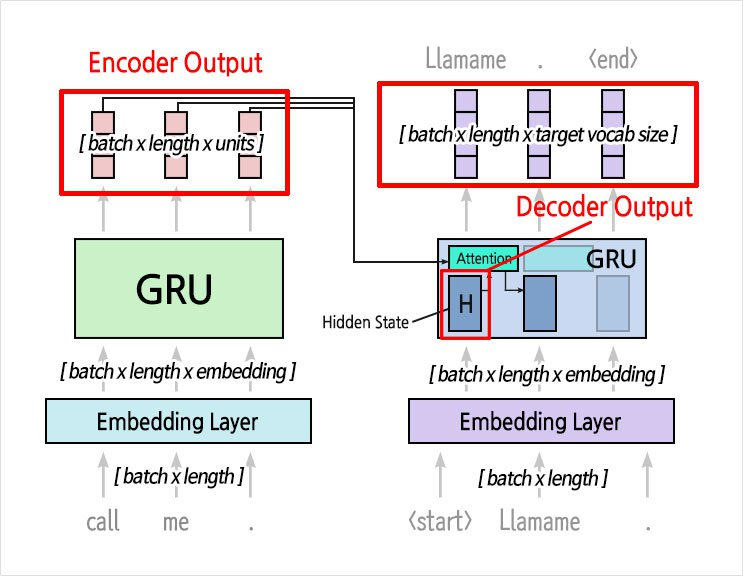

In [15]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)
        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [16]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)
            # outputs : (src_len, batch_size, hidden_dim)
            # hidden  : (1, batch_size, hidden_dim)

        return outputs, hidden

In [17]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # GRU 입력 크기 
        self.rnn = nn.GRU(emb_dim+hidden_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (1, batch_size, hidden_dim) (GRU 규격)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # 어텐션 계산을 위해 hidden의 맨 위 레이어 압축 해제 (batch_size, hidden_dim)
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a_weighted = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a_weighted, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        # 디코더 GRU 연산
        # Context와 Embedding 결합
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)

        # 가중치 결합 및 단어 예측
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a

In [18]:
import random

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    # teacher_forcing_ratio 추가 
    def forward(self, src, trg=None, max_len=30, bos_id=2, eos_id=3, teacher_forcing_ratio=0.5):
        # 토큰 사전에 맞춰 bos_id=2(<start>), eos_id=3(<end>)으로 매핑
        batch_size = src.shape[1]

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []
        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더 연산을 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 교사 강요(Teacher Forcing) 학습 모드
            input = trg[0] # <start>
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)

                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                teacher_force = random.random() < teacher_forcing_ratio
                top1 = output.argmax(1)

                # teacher forcing 여부 결정
                if t < trg.shape[0]-1:
                    input = trg[t+1] if teacher_force else top1

        else:
		    # 추론(Inference) 테스트 모드
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [19]:
# 하이퍼파라미터 정의
input_dim = len(kor_word2idx)  # 한국어 사전 크기
output_dim = 15000 # 영어 사전 크기
emb_dim = 256                  # 적당한 임베딩 사이즈 실험값
hid_dim = 512                  # 적당한 임베딩 사이즈 실험값

# 레이어 조립
attention = BahdanauAttention(hid_dim).to(device)
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)

# 모델 객체 생성
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)
print("모델 설계 및 빌드 완료")

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(15000, 256)
    (rnn): GRU(768, 512)
    (fc_out): Linear(in_features=1024, out_features=15000, bias=True)
  )
)
모델 설계 및 빌드 완료


## 훈련하기 

### (1) Optimizer & Loss

Optimizer : 모델이 학습할 때에 정답을 찾아가는 방법. 일반적으로 Adam 사용 

In [20]:
# 타겟 언어는 영어. 영어 사전의 패딩 인덱스 지정함. 
pad_id = eng_word2idx['<pad>']
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
    # . CrossEntropyLoss()
    #      모델이 출력한 확률 분포와 (One-hot이 아닌) 정수 인덱스 답안을 비교하여 Cross Entroypy 값을 구해줌. 
    #      => e.g. [ 0.1, 0.2, 0.7 ] 과 정수 인덱스 답안 2 를 비교하여 점수를 채점
    #  ignore_index = pad_id : pad 토큰은 무시 

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("손실함수 및 옵티마이저 설정 완료!")

손실함수 및 옵티마이저 설정 완료!


### (2) train_step 구현하기

학습에 필요한 것을 모두 가져가 Loss를 계산한 후 반환하는 함수

In [26]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()  # 모델을 학스 모드로 전환
    epoch_loss = 0  # epoch의 loss을 0으로 초기화

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    # data_loader에서 한 번의 연산에 사용할 src(소스 문장), trg_input(디코더 입력용 정답),
    # trg_label(손실 계산용 정답) 배치 가져옴
    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        # .permute()
        #   차원 변환. RNN/Transformer 계열 레이어 입력 규격(Sequence Lenght, Batch size) 형태로 차원 맞추기 위해
        #   축을 전환(permute)

        optimizer.zero_grad()   # 이전 배치에서 계산된 기울기를 초기화

        # 인코더와 디코더가 결합된 통합 model에 소스 문장과 타겟 입력 문장 전체를 동시 주입
        # outputs : 모든 시점(Time-step)의 예측 단어 분포
        outputs,_ = model(src, trg_input, teacher_forcing_ratio = 0.5)

        # 손실 계산을 위한 형태 변환
        # 3차원 형태의 예측값과 2차원 형태의 정답 레이블을 CrossEntropy 손실 함수가 인식할 수 있도록,
        # 배치와 시점을 하나로 묶어서 2차원 행렬과 1차원 벡터 형태로 평평하게 펼침
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])  # outputs: (batch_size * trg_len, output_dim)
        trg_label = trg_label.reshape(-1)  # trg_label: (batch_size * trg_len)
        
        # 손실 구하기 및 역전파
        loss = criterion(outputs, trg_label)
        loss.backward()

        # 그라디언트 클리핑
        # .nn.utils.clip_grad_norm_():
        #    기울기가 지나치게 커서 학습이 망가지는 현상을 막기 위해 기울기의 최대 크기를 1로 제한
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()  # 가중치 업데이트

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)  # 평균 손실 값 반환

print("Train_step 구현 완료!")


Train_step 구현 완료!


### (3) 훈련 수행

In [27]:
# 1. 디코더 입력(trg_input)과 정답(trg_label) 분리 (Teacher Forcing을 위한 한 칸 시프트)
# eng_tensor 구조: [<start>, 단어1, 단어2, ..., <end>, <pad>, ...]
# trg_input: 마지막 <end> 또는 <pad>를 제외하고 입력으로 사용
#    e.g.  ["<start>", "I", "am", "a", "boy"]
# trg_label: 맨 앞 <start>를 제외하고 손실 계산용 정답으로 사용
#    e.g. ["I", "am", "a", "boy", "<end>"]
trg_input = eng_tensor[:, :-1]
trg_label = eng_tensor[:, 1:]

# 2. TensorDataset으로 한국어, 영어 입력, 영어 정답을 하나로 묶기
train_dataset = TensorDataset(kor_tensor, trg_input, trg_label)

# 3. 퀘스트용 DataLoader 생성 (학습이므로 shuffle=True)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    pin_memory=True)

print(f"데이터로더 생성 완료! 총 배치의 개수: {len(train_loader)}")
print("이제 아래의 Epoch 학습 루프를 돌리시면 슝~ 하고 학습이 시작됩니다!")

데이터로더 생성 완료! 총 배치의 개수: 981
이제 아래의 Epoch 학습 루프를 돌리시면 슝~ 하고 학습이 시작됩니다!


### 번역 성능 평가 (Attention Map 시각화 추가) 

In [28]:
%%time

EPOCHS = 40
 
for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 981/981 [06:33<00:00,  2.50it/s, loss=5.49]


Epoch 1/40, Train Loss: 5.7938


Epoch 2: 100%|██████████| 981/981 [06:33<00:00,  2.49it/s, loss=5.12]


Epoch 2/40, Train Loss: 4.9488


Epoch 3: 100%|██████████| 981/981 [06:34<00:00,  2.49it/s, loss=4.31]


...

Epoch 38/40, Train Loss: 1.8467


Epoch 39: 100%|██████████| 981/981 [06:31<00:00,  2.50it/s, loss=1.78]


Epoch 39/40, Train Loss: 1.8346


Epoch 40: 100%|██████████| 981/981 [06:30<00:00,  2.51it/s, loss=2.07]

Epoch 40/40, Train Loss: 1.8131
CPU times: user 4h 19min 16s, sys: 1min 16s, total: 4h 20min 33s
Wall time: 4h 21min 18s


In [34]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocessing(sentence, is_source=True)
    # 입력받은 한글 문자열 형태소 토큰화
    tokens = morphs(sentence)
    
    # 위에서 이미 만들어둔 딕셔너리로 숫자 매칭 
    src_ids = [kor_word2idx.get(token, kor_word2idx['<unk>']) for token in tokens]
    
    # 최대 길이에 맞춰 슬라이싱 및 패딩 조절
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [kor_word2idx['<pad>']] * (max_len - len(src_ids))
    
    # 모델 입력 규격에 맞게 변환 (src_len, batch_size=1)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    # 출력을 가장 확률이 높은 단어 인덱스로 변환 후 영어 단어로 디코딩
    predicted_ids = outputs.argmax(2).squeeze(1).cpu().tolist()
    
    result = []
    for idx in predicted_ids:
        word = eng_idx2word.get(idx, '<unk>')
        if word == '<end>': 
            break
        if word not in ['<pad>', '<start>']: 
            result.append(word)

    # 어텐션 행렬 추출
    attention_matrix = attentions.squeeze(1).cpu().numpy()
    
    return result, tokens, attention_matrix

In [35]:
plt.rc('font', family='NanumGothic')

def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    # 시각화할 때 실제 예측된 단어 길이와 입력된 토큰 길이만큼 행렬을 잘라줌
    ax.matshow(attention[:len(predicted_sentence), :len(sentence)], cmap='viridis')

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, rotation=90, fontsize=12)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontsize=12)

    plt.show()

    plt.show()

In [36]:
def translate(sentence, model, kor_word2idx, eng_idx2word, max_len=40):
    # evaluate 함수를 통해 번역 결과물과 토큰 리스트, 어텐션 가중치를 수령
    result, tokens, attention = evaluate(sentence, model, kor_word2idx, eng_idx2word, max_len)

    print('Input (Tokens):', tokens)
    print('Predicted translation:', ' '.join(result))

    # 차원 정합성을 위해 가중치 행렬과 라벨의 길이를 맞춰 시각화 호출
    plot_attention(attention, tokens, result)

In [37]:
print(list(eng_idx2word.items())[:20])

[(0, '<pad>'), (1, '<unk>'), (2, '<start>'), (3, '<end>'), (4, '.'), (5, 'the'), (6, '<start>'), (7, '<end>'), (8, ','), (9, 'to'), (10, 'of'), (11, 'a'), (12, 'in'), (13, 'and'), (14, 's'), (15, 'The'), (16, 'said'), (17, 'for'), (18, 'on'), (19, 'is')]


Input (Tokens): ['오바마', '는', '대통령', '이', '다', '.']
Predicted translation: Obama is


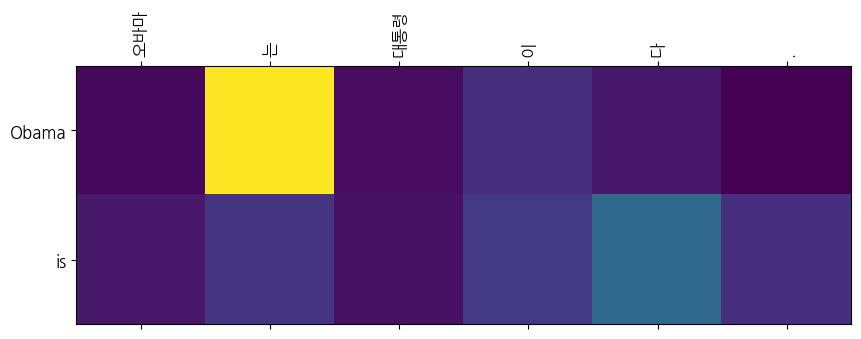

In [43]:
# 예시문으로 번역 성능 체크 

translate("오바마는 대통령이다.", model, kor_word2idx, eng_idx2word, max_len=40)

Input (Tokens): ['시민', '들', '은', '도시', '속', '에', '산다', '.']
Predicted translation: citizens for a cities


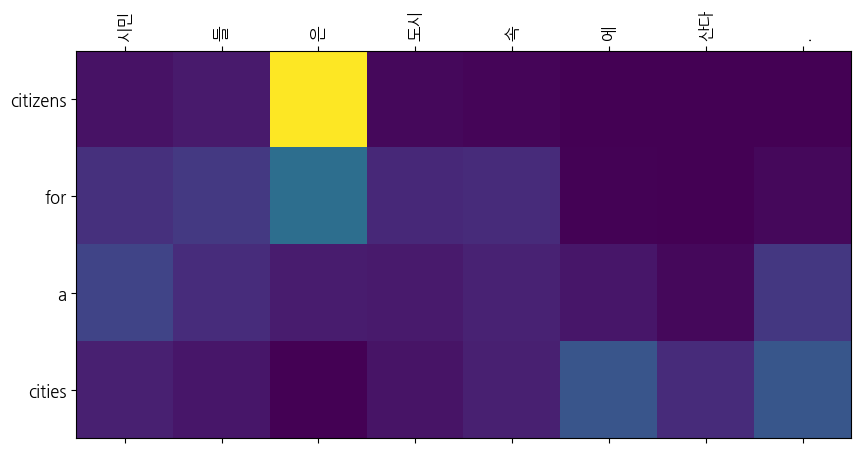

In [44]:
translate("시민들은 도시 속에 산다.", model, kor_word2idx, eng_idx2word, max_len=40)

Input (Tokens): ['커피', '는', '필요', '없', '다', '.']
Predicted translation: coffee is no need .


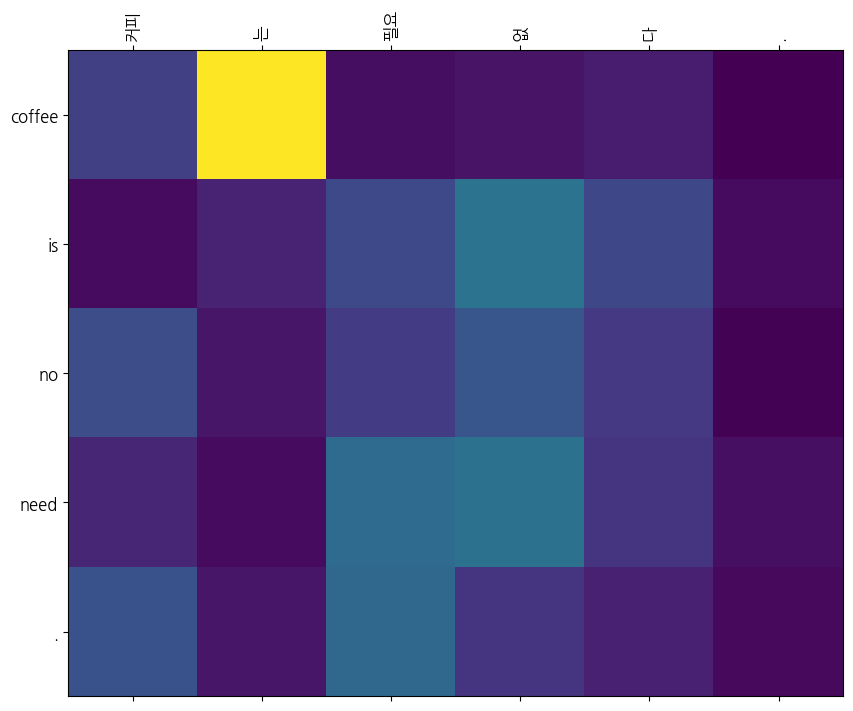

In [45]:
translate("커피는 필요 없다.", model, kor_word2idx, eng_idx2word, max_len=40)

Input (Tokens): ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
Predicted translation: dead person dead .


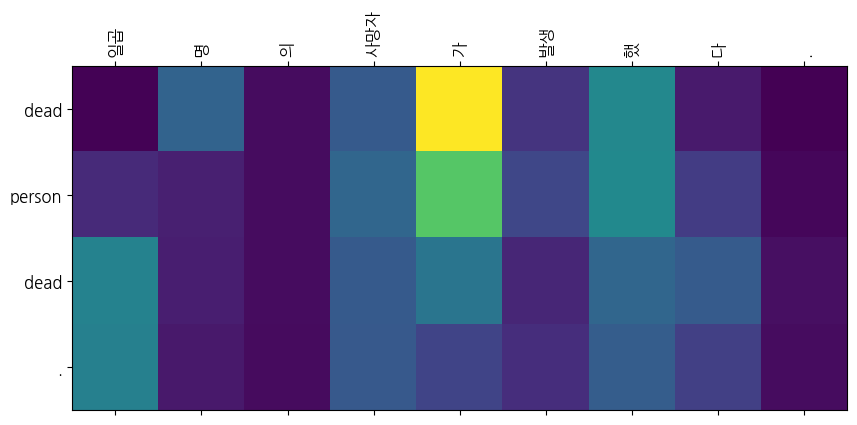

In [46]:
translate("일곱 명의 사망자가 발생했다.", model, kor_word2idx, eng_idx2word, max_len=40)

# Note 

---

```text
GPU를 쓰는 모델은 시간이 생각보다 많이 걸린다는 걸 뼈저리게 배웠다. 학습 도중에 꺼질까봐 뜬 눈으로 밤을 지세웠는데 번역 결과가 형편없어서 너무 허무하다. 
한글과 영어 연결이 얼추 유사한 예시도 있지만 번역의 질이 매우 떨어지는 예시도 존재했다. 그리고 입력 시퀀스와 출력 시퀀스 사이의 매칭을 그림으로 나타낸 표의 색상을 봐도 업데이트가 많이 필요한 모델이라는 것을 확인할 수 있다. 

일단은 바다나우 어텐션 메커니즘을 사용해서 seq2seq를 만들어봤다는 것에 의의를 두고, 이후에도 좀 더 모델을 발전시켜볼 생각이다. 
```